# Aula 1 — Demonstração: generalização com dados de queda livre

**Introdução ao Aprendizado de Máquina · Física Computacional**

Este notebook com um problema de física simples, ele mostra os conceitos centrais da aula:

- divisão dos dados em treino e teste;
- subajuste e sobreajuste;
- escolha de um hiperparâmetro (o grau do polinômio) por validação cruzada, sem tocar no conjunto de teste.

## 0. Bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

AZUL, LARANJA, CINZA = "#2a78d6", "#eb6834", "#8a8984"

## 1. O "experimento"

Simulamos a medida da altura $y$ de um objeto em queda livre em $N = 30$ instantes entre 0 e 1 s, com erro de medida gaussiano de desvio padrão $\sigma = 0{,}15$ m. A lei verdadeira é

$$y(t) = h_0 - \tfrac{1}{2}\, g\, t^2, \qquad h_0 = 10\ \text{m}, \quad g = 9{,}8\ \text{m/s}^2 .$$

Num problema real de aprendizado de máquina não conheceríamos essa lei: teríamos apenas os pontos medidos.

In [3]:
rng = np.random.default_rng(28)

N, h0, g, sigma = 30, 10.0, 9.8, 0.15
t = np.sort(rng.uniform(0, 1, N))                   # tempo (s)
y = h0 - 0.5 * g * t**2 + rng.normal(0, sigma, N)   # altura medida (m)

def lei_verdadeira(t):
    return h0 - 0.5 * g * t**2

T = t.reshape(-1, 1)   # o scikit-learn espera uma matriz (N amostras x d atributos)
print("formato de t:", t.shape, "  formato de T:", T.shape, "  formato de y:", y.shape)

formato de t: (30,)   formato de T: (30, 1)   formato de y: (30,)


In [6]:
T.shape

(30, 1)

> **Atenção:** o scikit-learn sempre espera $X$ no formato (*N* amostras × *d* atributos), mesmo quando há um único atributo. Por isso usamos `t.reshape(-1, 1)`. Esquecer isso é um dos erros mais comuns na primeira prática.

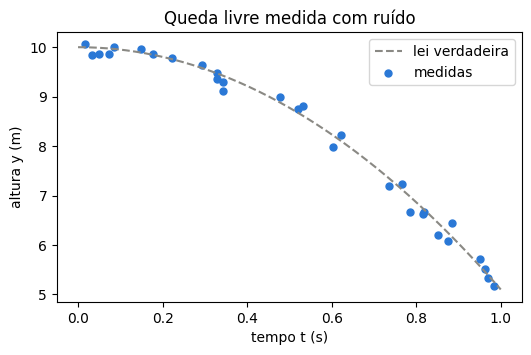

In [9]:
tt = np.linspace(0, 1, 400)

plt.figure(figsize=(6, 3.5))
plt.plot(tt, lei_verdadeira(tt), "--", color=CINZA, label="lei verdadeira")
plt.scatter(t, y, s=25, color=AZUL, label="medidas")
plt.xlabel("tempo t (s)")
plt.ylabel("altura y (m)")
plt.title("Queda livre medida com ruído")
plt.legend()
plt.show()

## 2. Divisão treino/teste

Separamos 70% dos pontos para **treino** e 30% para **teste**. O conjunto de teste fica guardado: ele não será usado em nenhuma decisão, apenas para estimar o desempenho final.

treino: 21 pontos   |   teste: 9 pontos


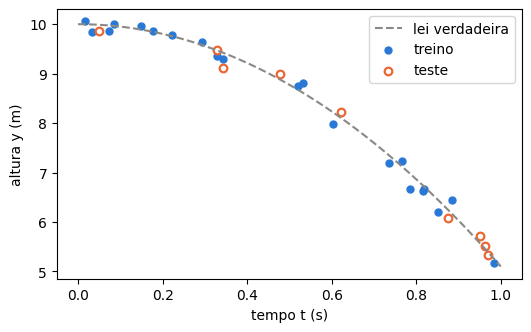

In [10]:
T_tr, T_te, y_tr, y_te = train_test_split(T, y, test_size=0.3, random_state=0)
print(f"treino: {len(y_tr)} pontos   |   teste: {len(y_te)} pontos")

plt.figure(figsize=(6, 3.5))
plt.plot(tt, lei_verdadeira(tt), "--", color=CINZA, label="lei verdadeira")
plt.scatter(T_tr, y_tr, s=25, color=AZUL, label="treino")
plt.scatter(T_te, y_te, s=30, facecolor="white", edgecolor=LARANJA, linewidth=1.6, label="teste")
plt.xlabel("tempo t (s)")
plt.ylabel("altura y (m)")
plt.legend()
plt.show()

## 3. Mesmo problema, três modelos

Ajustamos polinômios de grau 1, 2 e 15 **apenas aos dados de treino**. O `PolynomialFeatures` transforma cada $t$ no vetor $(1, t, t^2, \dots, t^p)$ e a `LinearRegression` encontra os coeficientes por mínimos quadrados. O `make_pipeline` encadeia as duas etapas num único modelo, com a interface `fit`/`predict`.

> **Pergunta para a turma:** qual grau terá o **menor erro de treino**? E qual terá o **menor erro de teste**?

In [11]:
modelos = {} # Cria um dicionário vazio para guardar os modelos treinados, identificados pelo grau do polinômio.
for grau in [1, 2, 15]: # Repete o bloco para polinômios de graus 1, 2 e 15.

    #Cria uma sequência de duas etapas: gera características polinomiais (como T, T^2, etc.) e aplica regressão linear para ajustar seus coeficientes.
    # ajuste linear nos coeficiente y = a_0 + a_1T + a_2T^2 + a_3T^3
    # Um pipeline é uma sequência de etapas: a saída de uma vira a entrada da próxima.
    modelo = make_pipeline(PolynomialFeatures(grau), LinearRegression())

    modelo.fit(T_tr, y_tr) #Treina o modelo
    modelos[grau] = modelo #Guarda o modelo treinado no dicionário. Por exemplo, modelos[2] permite acessar o modelo de grau 2.
    eqm_tr = mean_squared_error(y_tr, modelo.predict(T_tr)) #Calcula o erro quadrático médio (EQM) no treino
    eqm_te = mean_squared_error(y_te, modelo.predict(T_te)) #Calcula o erro quadrático médio (EQM) no teste
    print(f"grau {grau:2d}: EQM treino = {eqm_tr:.3f} | EQM teste = {eqm_te:.3f}")

print(f"\nruído das medidas: sigma^2 = {sigma**2:.4f}")

grau  1: EQM treino = 0.144 | EQM teste = 0.248
grau  2: EQM treino = 0.021 | EQM teste = 0.023
grau 15: EQM treino = 0.005 | EQM teste = 42.558

ruído das medidas: sigma^2 = 0.0225


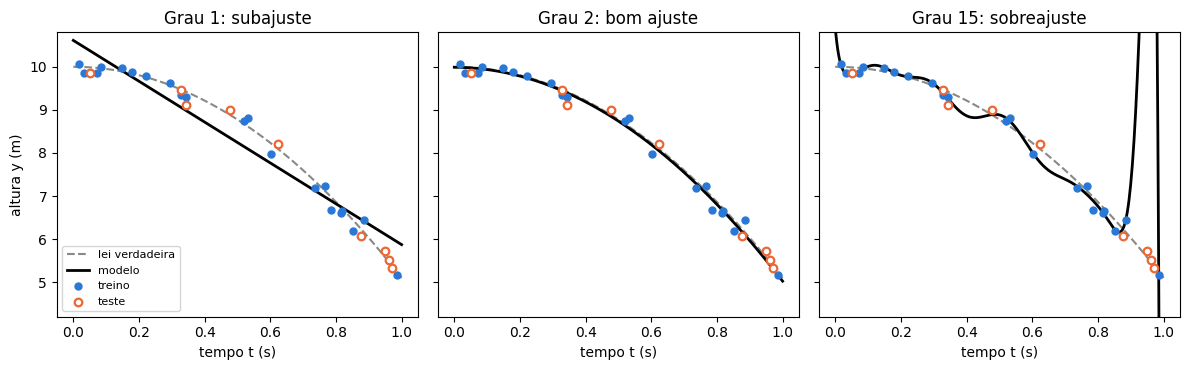

In [12]:
titulos = {1: "Grau 1: subajuste", 2: "Grau 2: bom ajuste", 15: "Grau 15: sobreajuste"}
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, grau in zip(axs, [1, 2, 15]):
    ax.plot(tt, lei_verdadeira(tt), "--", color=CINZA, label="lei verdadeira")
    ax.plot(tt, modelos[grau].predict(tt.reshape(-1, 1)), color="black", lw=2, label="modelo")
    ax.scatter(T_tr, y_tr, s=25, color=AZUL, zorder=3, label="treino")
    ax.scatter(T_te, y_te, s=30, facecolor="white", edgecolor=LARANJA, linewidth=1.6, zorder=3, label="teste")
    ax.set_title(titulos[grau])
    ax.set_xlabel("tempo t (s)")
    ax.set_ylim(4.2, 10.8)
axs[0].set_ylabel("altura y (m)")
axs[0].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

**O que observar**

- O erro de **treino** sempre diminui com o grau: o polinômio de grau 15 contém o de grau 2 como caso particular, então nunca ajusta pior os mesmos pontos.
- O erro de **teste** do grau 2 é praticamente $\sigma^2 = 0{,}0225$: o ruído das medidas não pode ser previsto por nenhum modelo (erro irredutível).
- O grau 15 tem erro de treino **menor** que $\sigma^2$: ele está "explicando" o ruído. É o sobreajuste.
- O grau 15 diverge perto de $t = 1$ s: modelos muito flexíveis são especialmente ruins na borda dos dados e fora dela (extrapolação).

## 4. Escolhendo o grau por validação cruzada

Na prática não sabemos o grau correto. Para escolhê-lo **sem usar o conjunto de teste**, aplicamos validação cruzada com 5 dobras **só aos dados de treino**: o treino é dividido em 5 partes, o modelo é treinado 5 vezes (cada vez validando numa parte diferente) e os 5 erros são promediados.

O scikit-learn segue a convenção "maior é melhor" para as métricas, por isso devolve o EQM com sinal negativo (`neg_mean_squared_error`). Trocamos o sinal para voltar ao EQM.

grau 1: EQM de validação cruzada = 0.252
grau 2: EQM de validação cruzada = 0.034
grau 3: EQM de validação cruzada = 0.036
grau 4: EQM de validação cruzada = 0.099
grau 5: EQM de validação cruzada = 0.151
grau 6: EQM de validação cruzada = 0.283
grau 7: EQM de validação cruzada = 0.724
grau 8: EQM de validação cruzada = 13.131


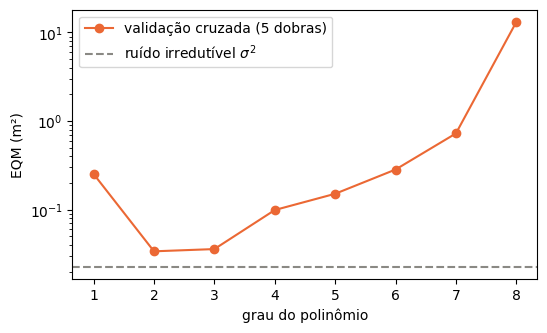

In [13]:
#Define validação cruzada com 5 partes: treina em 4 e valida na restante, alternando.
#Embaralha os dados com uma semente fixa para reproduzir a divisão.
kf = KFold(n_splits=5, shuffle=True, random_state=0)
graus = range(1, 9) #Define os graus de 1 a 8.
eqm_cv = [] #Cria uma lista para armazenar os erros médios.
for grau in graus:
    modelo = make_pipeline(PolynomialFeatures(grau), LinearRegression())

    #Treina e avalia o modelo nas 5 divisões.
    #Retorna 5 valores de EQM negativo, conforme a convenção do scikit-learn:
    #pontuações maiores são melhores.
    s = cross_val_score(modelo, T_tr, y_tr, cv=kf, scoring="neg_mean_squared_error")
    eqm_cv.append(-s.mean()) #Calcula a média, inverte o sinal para obter o EQM positivo e guarda na lista.
    print(f"grau {grau}: EQM de validação cruzada = {-s.mean():.3f}")

#Figura
plt.figure(figsize=(6, 3.5))
plt.semilogy(list(graus), eqm_cv, "o-", color=LARANJA, label="validação cruzada (5 dobras)")
plt.axhline(sigma**2, ls="--", color=CINZA, label="ruído irredutível $\\sigma^2$")
plt.xlabel("grau do polinômio")
plt.ylabel("EQM (m²)")
plt.legend()
plt.show()

Escolhido o grau, treinamos o modelo final com todo o conjunto de treino e o avaliamos **uma única vez** no conjunto de teste.

In [20]:
list(graus)

[1, 2, 3, 4, 5, 6, 7, 8]

In [21]:
#np.argmin encontra a posição do menor erro de validação cruzada.
#Essa posição identifica o grau escolhido na lista graus.
grau_escolhido = list(graus)[int(np.argmin(eqm_cv))]

#Cria o modelo com o grau escolhido e o treina usando todos os dados de treino.
modelo_final = make_pipeline(PolynomialFeatures(grau_escolhido), LinearRegression()).fit(T_tr, y_tr)

#Faz previsões nos dados de teste e calcula o EQM em relação aos valores reais.
eqm_teste = mean_squared_error(y_te, modelo_final.predict(T_te))
print(f"grau escolhido pela validação cruzada: {grau_escolhido}")
print(f"EQM no teste (avaliado uma única vez): {eqm_teste:.3f}")

grau escolhido pela validação cruzada: 2
EQM no teste (avaliado uma única vez): 0.023


## 5. Bônus: o modelo "reencontra" a física

O polinômio de grau 2 tem a forma $\theta_0 + \theta_1 t + \theta_2 t^2$. Comparando com $y = h_0 + v_0 t - \tfrac{1}{2} g t^2$, os coeficientes ajustados estimam $h_0$, a velocidade inicial $v_0$ (que deveria ser zero, pois o objeto foi solto do repouso) e $g = -2\,\theta_2$.

Aqui a física nos deu a forma certa do modelo. Em aprendizado de máquina, em geral, não temos essa sorte, e por isso precisamos das ferramentas de validação que acabamos de ver.

In [26]:
#Acessa a regressão linear dentro do modelo de grau 2 já treinado.
#make_pipeline cria automaticamente o nome usando o nome da classe em minúsculas.
reg = modelos[2].named_steps["linearregression"]

#Obtém o termo constante, que representa a altura inicial \(h_0\)
theta0 = reg.intercept_ #intercept_ pega o termo constante, de ordem zero
theta1, theta2 = reg.coef_[1], reg.coef_[2]
print(f"h0 estimado = {theta0:.2f} m      (verdadeiro: 10 m)")
print(f"v0 estimado = {theta1:.2f} m/s    (verdadeiro: 0 m/s)")
print(f"g  estimado = {-2 * theta2:.2f} m/s^2  (verdadeiro: 9.8 m/s^2)")

h0 estimado = 9.99 m      (verdadeiro: 10 m)
v0 estimado = -0.04 m/s    (verdadeiro: 0 m/s)
g  estimado = 9.85 m/s^2  (verdadeiro: 9.8 m/s^2)


## 6. Se sobrar tempo

### 6.1 Mais dados reduzem o sobreajuste

A função abaixo repete o experimento com outro número de pontos ou outra semente. Com $N = 100$, o polinômio de grau 15 sobreajusta muito menos.

In [ ]:
def experimento(N, semente=28, graus=(1, 2, 15)):
    r = np.random.default_rng(semente)
    t = np.sort(r.uniform(0, 1, N))
    y = lei_verdadeira(t) + r.normal(0, sigma, N)
    T_tr, T_te, y_tr, y_te = train_test_split(t.reshape(-1, 1), y, test_size=0.3, random_state=0)
    print(f"N = {N}")
    for grau in graus:
        m = make_pipeline(PolynomialFeatures(grau), LinearRegression()).fit(T_tr, y_tr)
        print(f"  grau {grau:2d}: EQM treino = {mean_squared_error(y_tr, m.predict(T_tr)):.3f}"
              f" | EQM teste = {mean_squared_error(y_te, m.predict(T_te)):.3f}")

experimento(30)
experimento(100)

N = 30
  grau  1: EQM treino = 0.144 | EQM teste = 0.248
  grau  2: EQM treino = 0.021 | EQM teste = 0.023
  grau 15: EQM treino = 0.008 | EQM teste = 1.273
N = 100
  grau  1: EQM treino = 0.149 | EQM teste = 0.161
  grau  2: EQM treino = 0.021 | EQM teste = 0.026
  grau 15: EQM treino = 0.020 | EQM teste = 0.028


### 6.2 Variância: o modelo muda muito de um conjunto de dados para outro?

Repetimos o experimento com 5 sementes diferentes (5 "laboratórios" medindo o mesmo fenômeno) e sobrepomos os modelos ajustados. O grau 2 quase não muda; o grau 15 muda bastante. Isso é a **variância** da decomposição viés–variância.

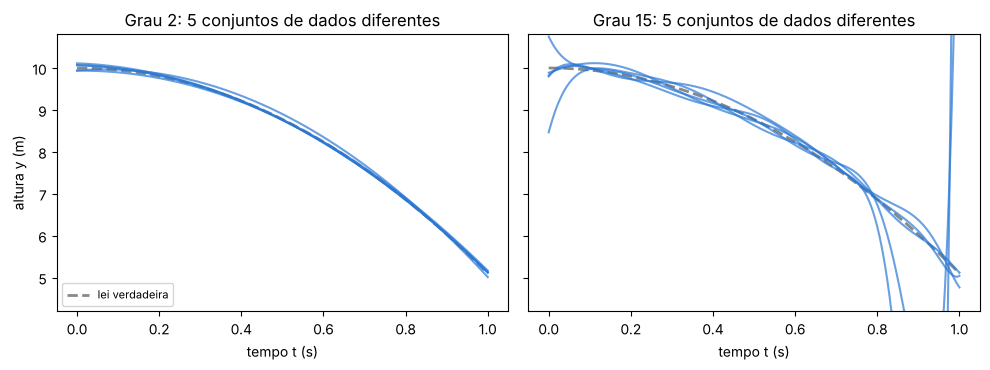

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, grau in zip(axs, [2, 15]):
    ax.plot(tt, lei_verdadeira(tt), "--", color=CINZA, lw=2, label="lei verdadeira")
    for semente in range(5):
        r = np.random.default_rng(semente)
        ts = np.sort(r.uniform(0, 1, 30))
        ys = lei_verdadeira(ts) + r.normal(0, sigma, 30)
        Ts_tr, _, ys_tr, _ = train_test_split(ts.reshape(-1, 1), ys, test_size=0.3, random_state=0)
        m = make_pipeline(PolynomialFeatures(grau), LinearRegression()).fit(Ts_tr, ys_tr)
        ax.plot(tt, m.predict(tt.reshape(-1, 1)), color=AZUL, alpha=0.7, lw=1.5)
    ax.set_title(f"Grau {grau}: 5 conjuntos de dados diferentes")
    ax.set_xlabel("tempo t (s)")
    ax.set_ylim(4.2, 10.8)
axs[0].set_ylabel("altura y (m)")
axs[0].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()